# Esperimento  sull'agent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [38]:
RESULT_TOT="../data/training_dataset/results/results_combined_new_model_name.csv"
colors = cm.tab10.colors
df = pd.read_csv(RESULT_TOT)
df['model'].unique()

<StringArray>
[                'qwen-chat-agent-4-v2',
                       'chat-qwen-base',
                    'qwen-chat-agent-6',
                     'qwen-extractor-3',
                     'qwen-extractor-4',
                     'qwen-extractor-2',
 'qwen-chat-extractor-tuned-lora-16-v1',
                 'qwen-chat-agent-5-v1',
                    'qwen-chat-agent-7',
       'qwen-chat-agent-8-wo-embedding',
                   'qwen-chat-agent-12']
Length: 11, dtype: str

In [39]:
target ='base|chat-agent'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen-agent-v3-rollout8','qwen-base','qwen-agent-v4-rollout8','qwen-agent-rollout5-v1','qwen-agent-rollout10','qwen-agent-rollout5-wo-embedding',
            'qwen-agent-rollout5-v1(dense reward)'
            ]
models

['qwen-chat-agent-4-v2',
 'chat-qwen-base',
 'qwen-chat-agent-6',
 'qwen-chat-agent-5-v1',
 'qwen-chat-agent-7',
 'qwen-chat-agent-8-wo-embedding',
 'qwen-chat-agent-12']

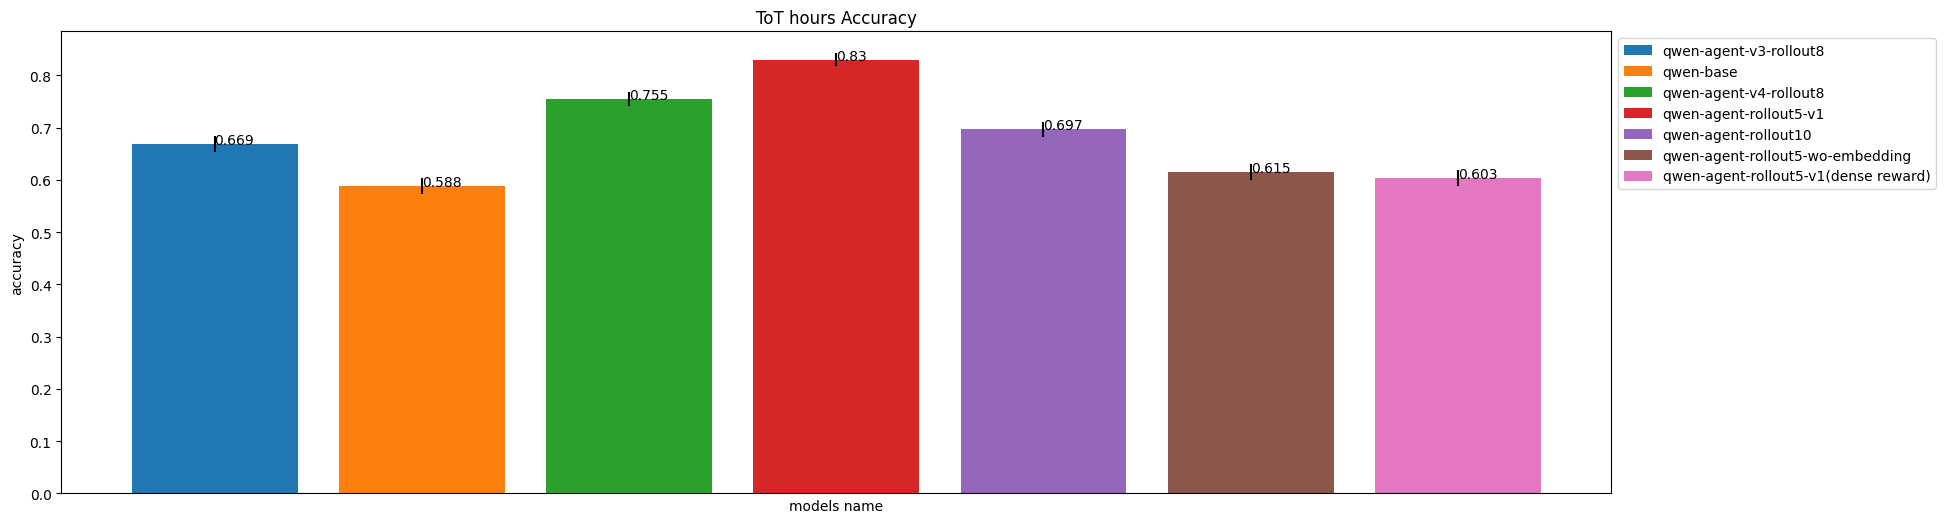

In [40]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    acc_media = round(df.loc[(df['model'] == model)  ]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors , label=labels)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

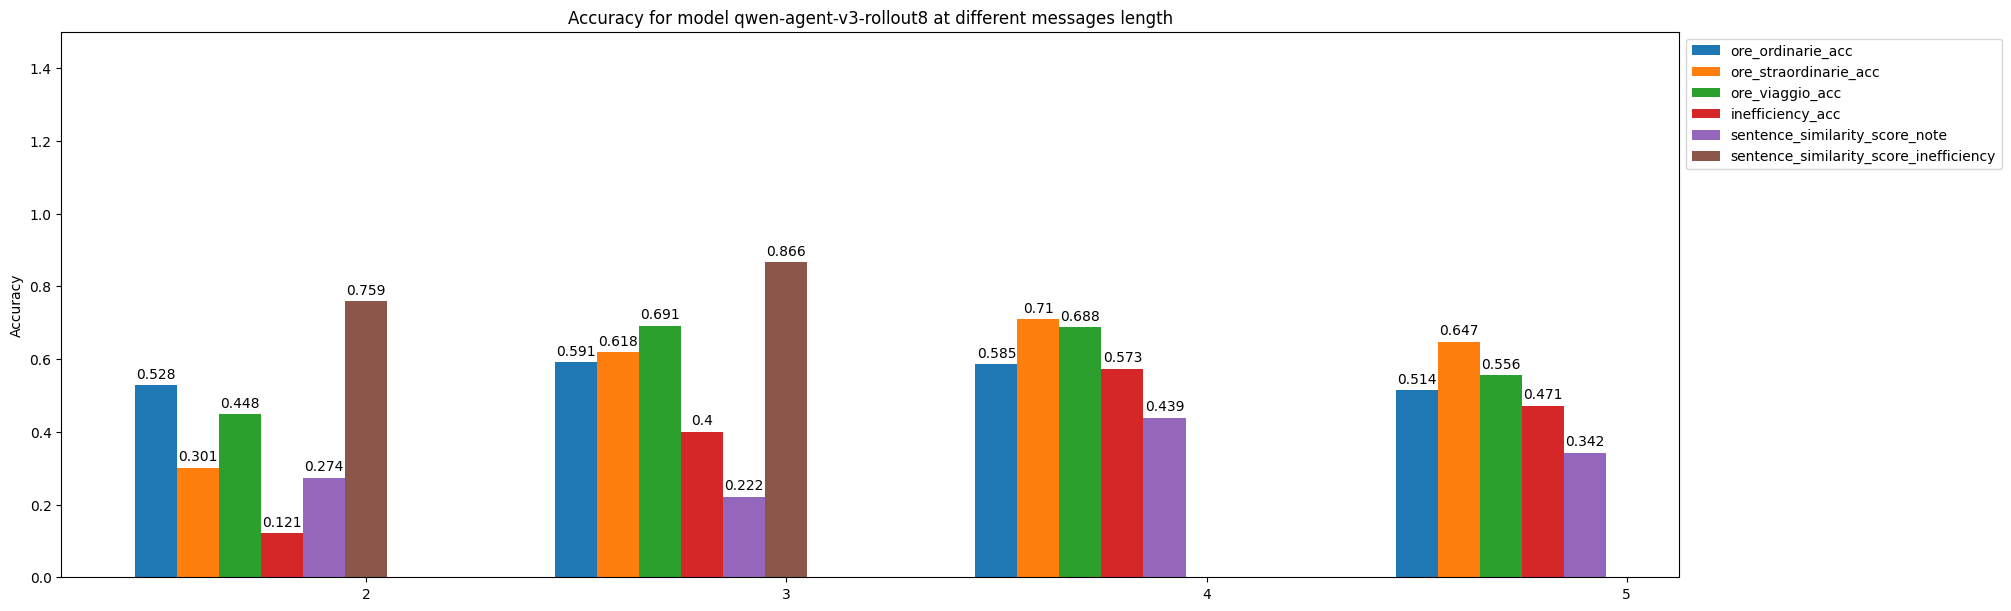

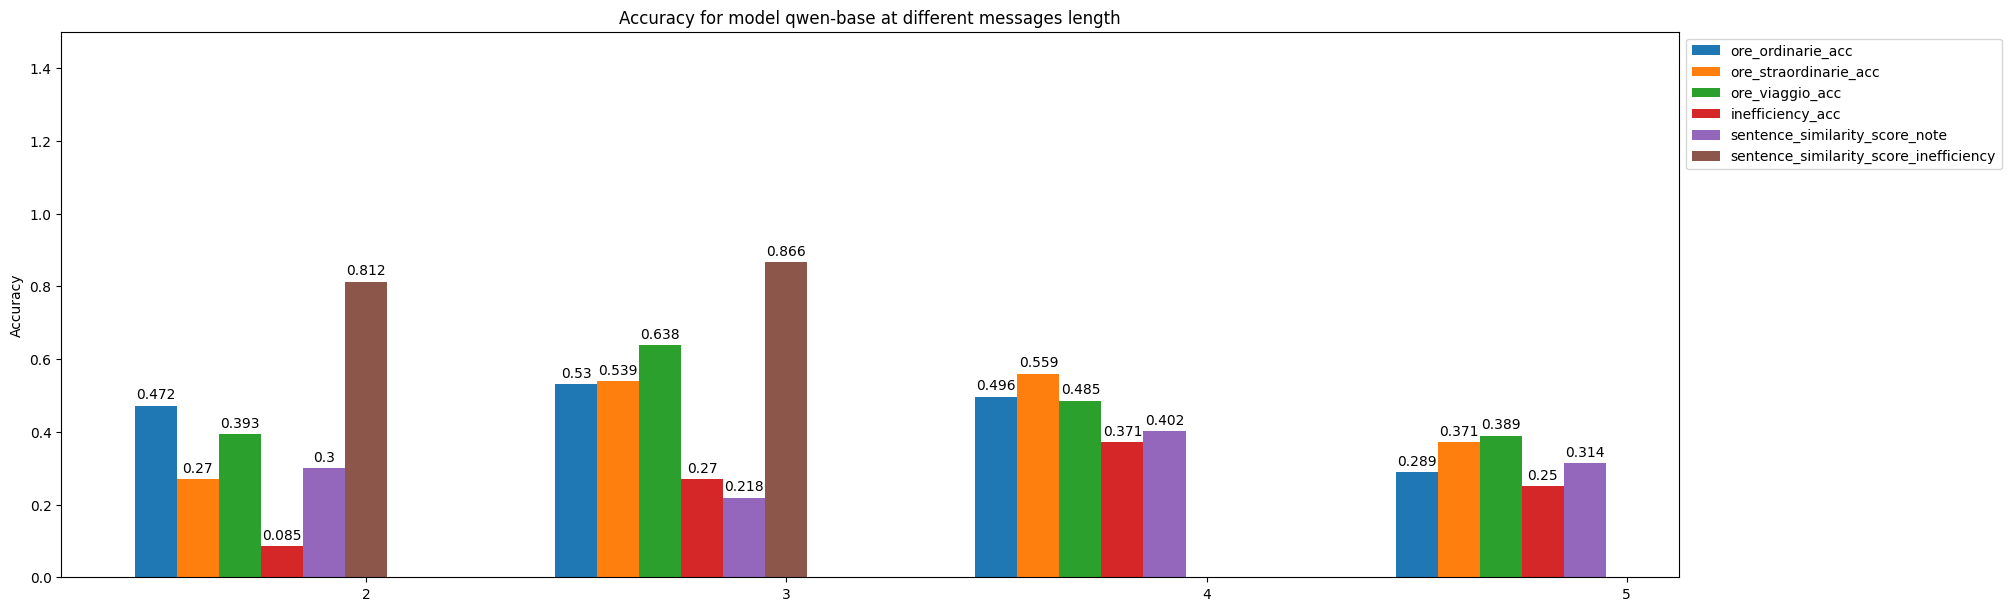

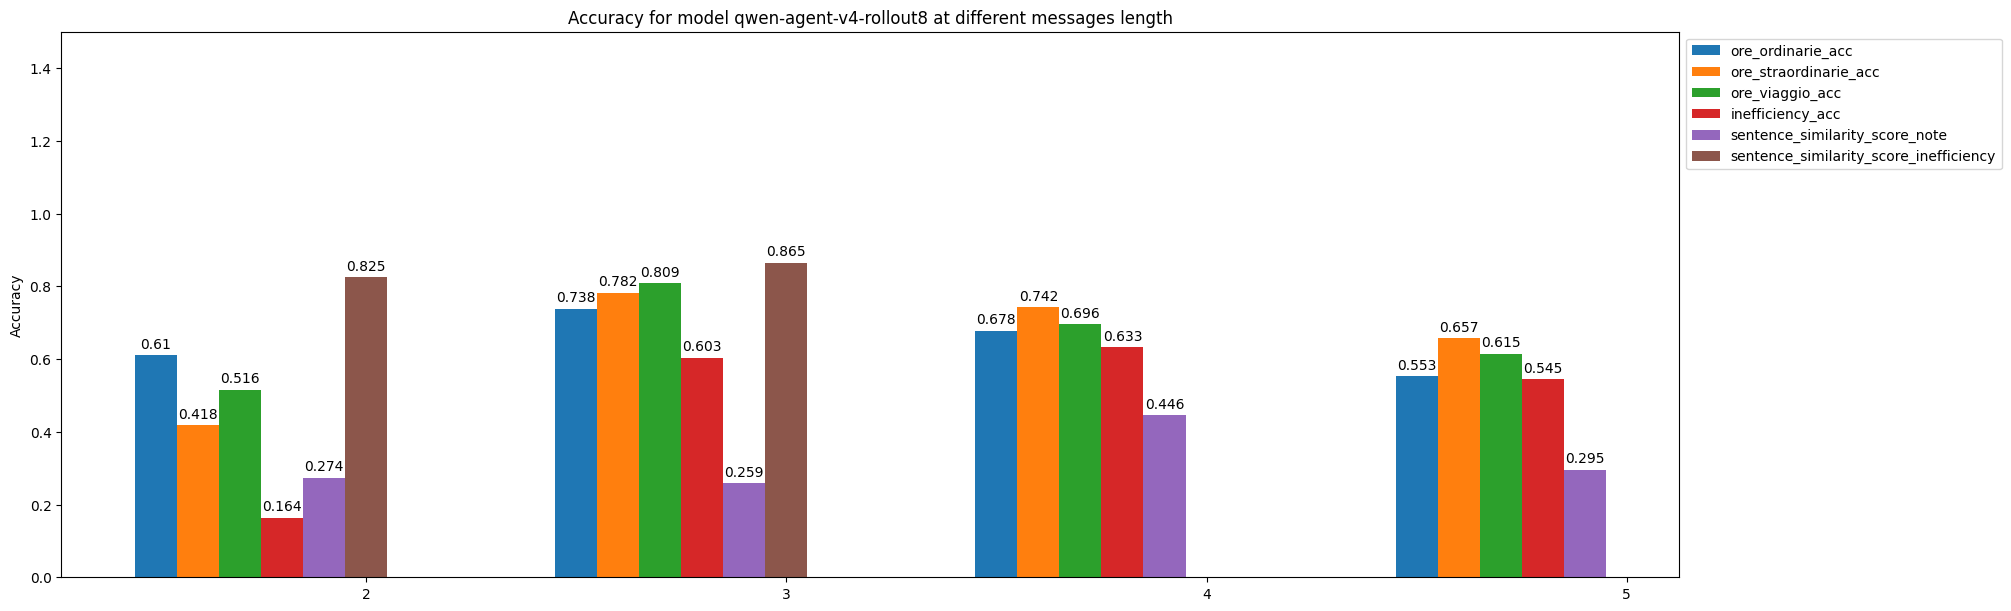

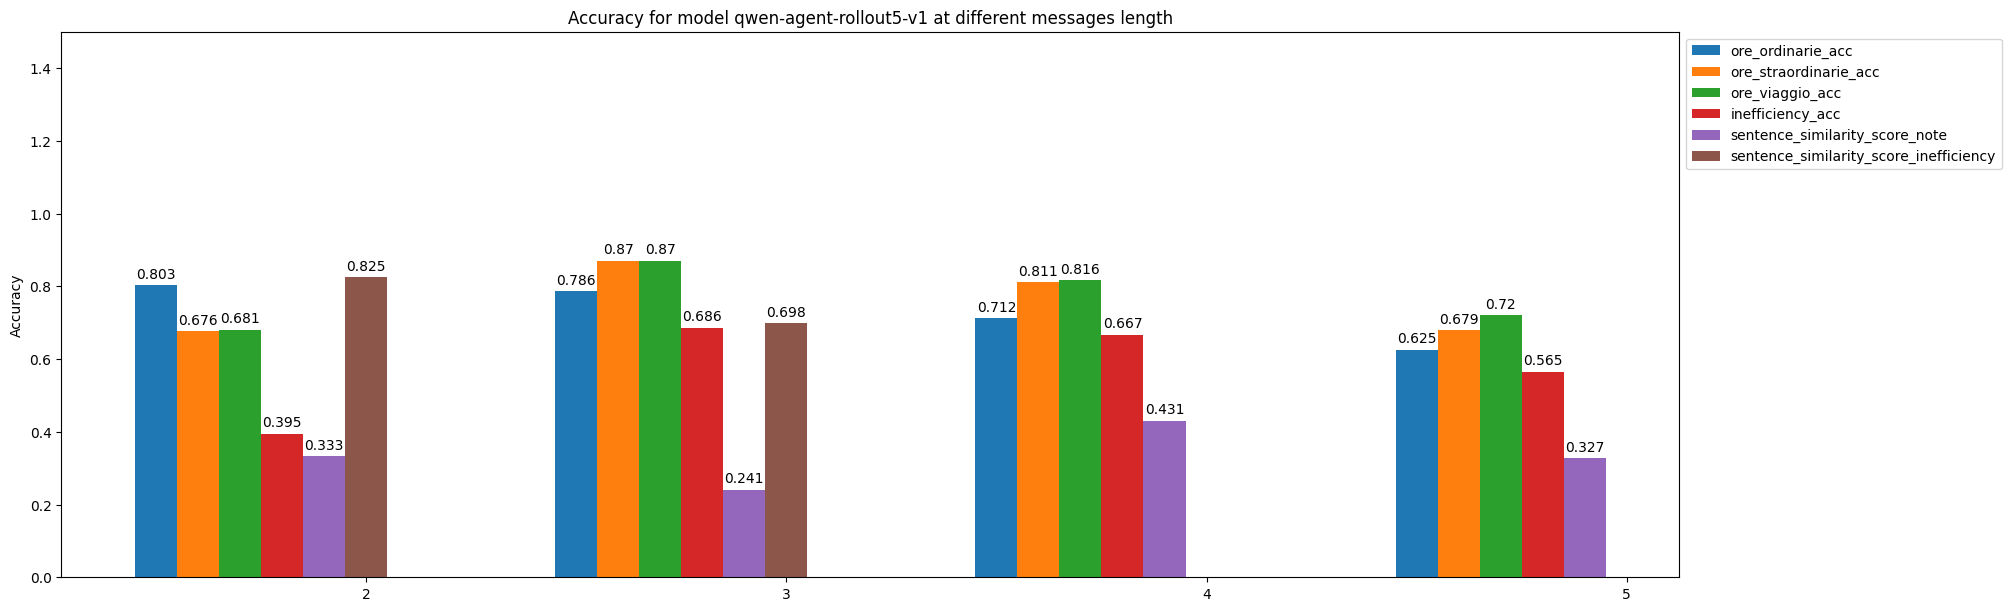

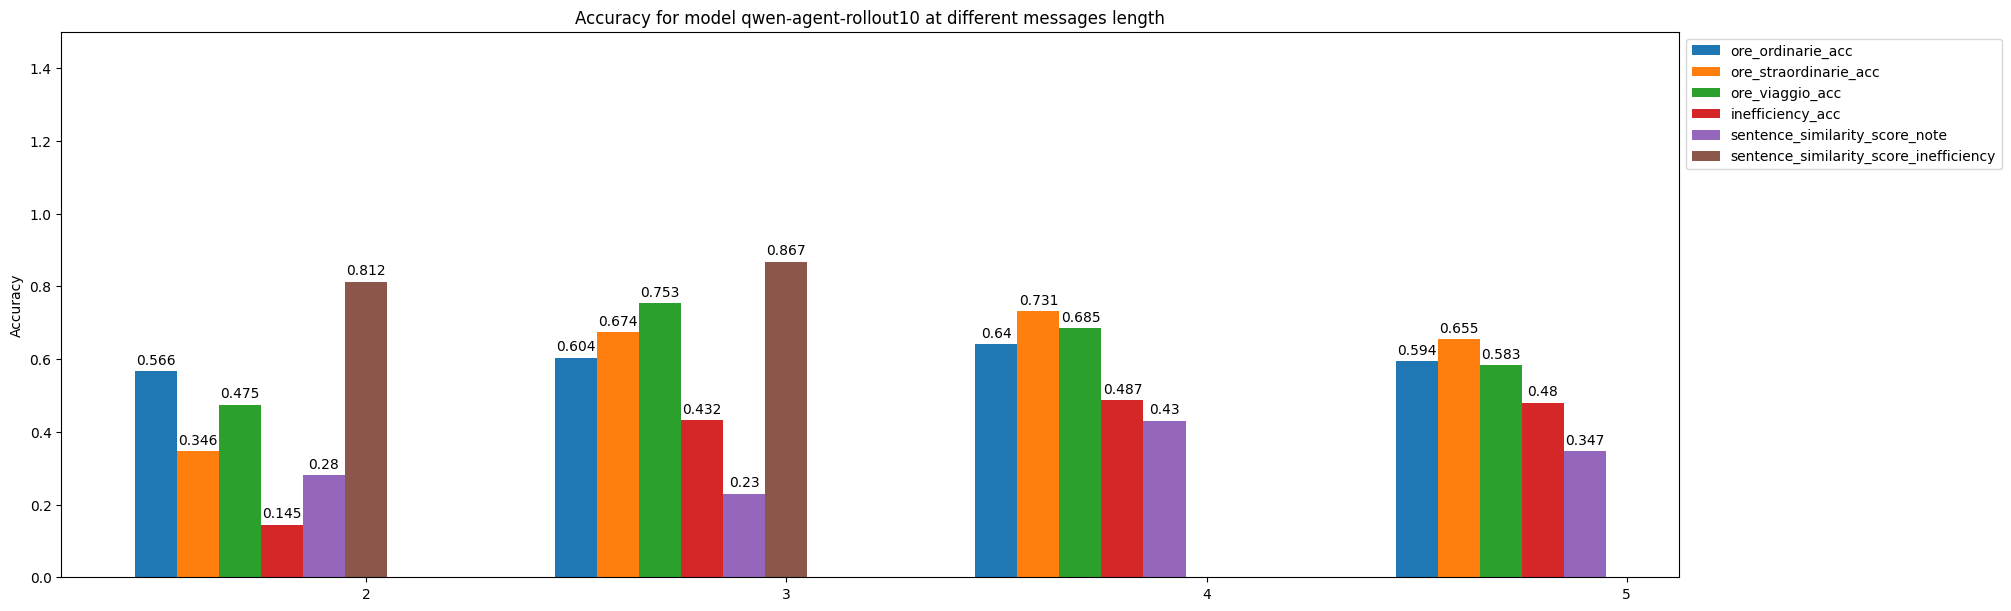

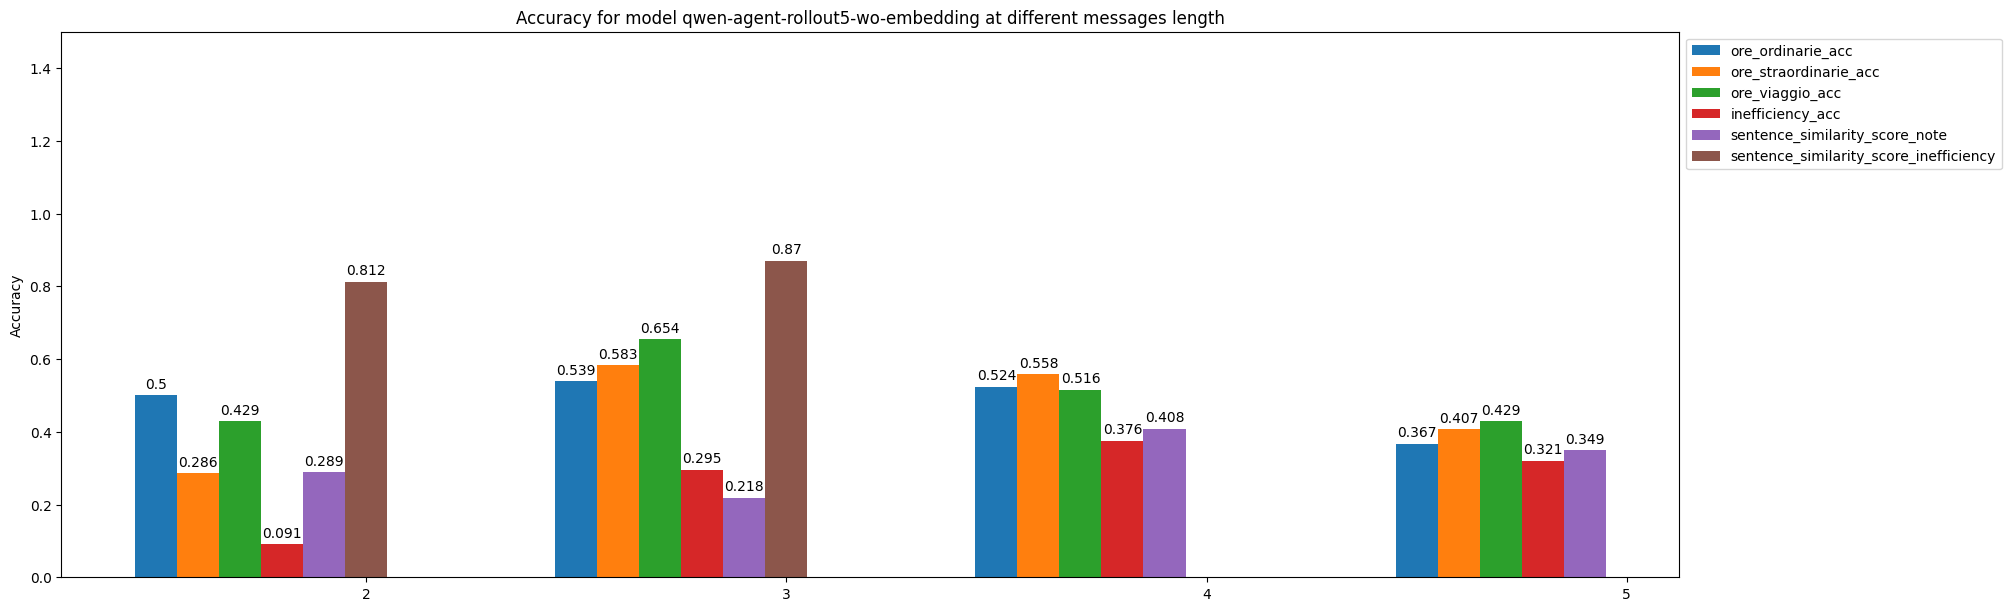

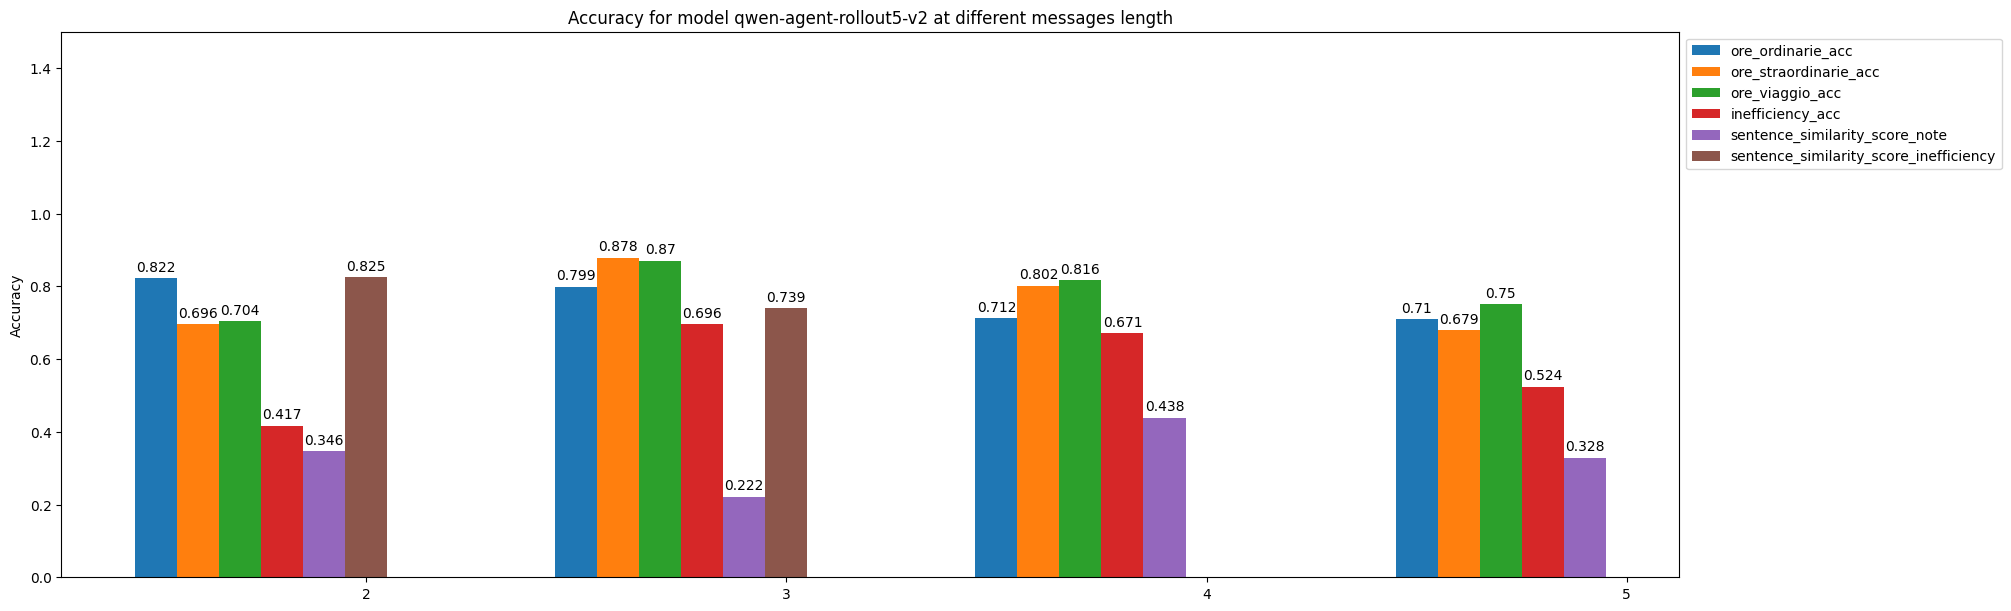

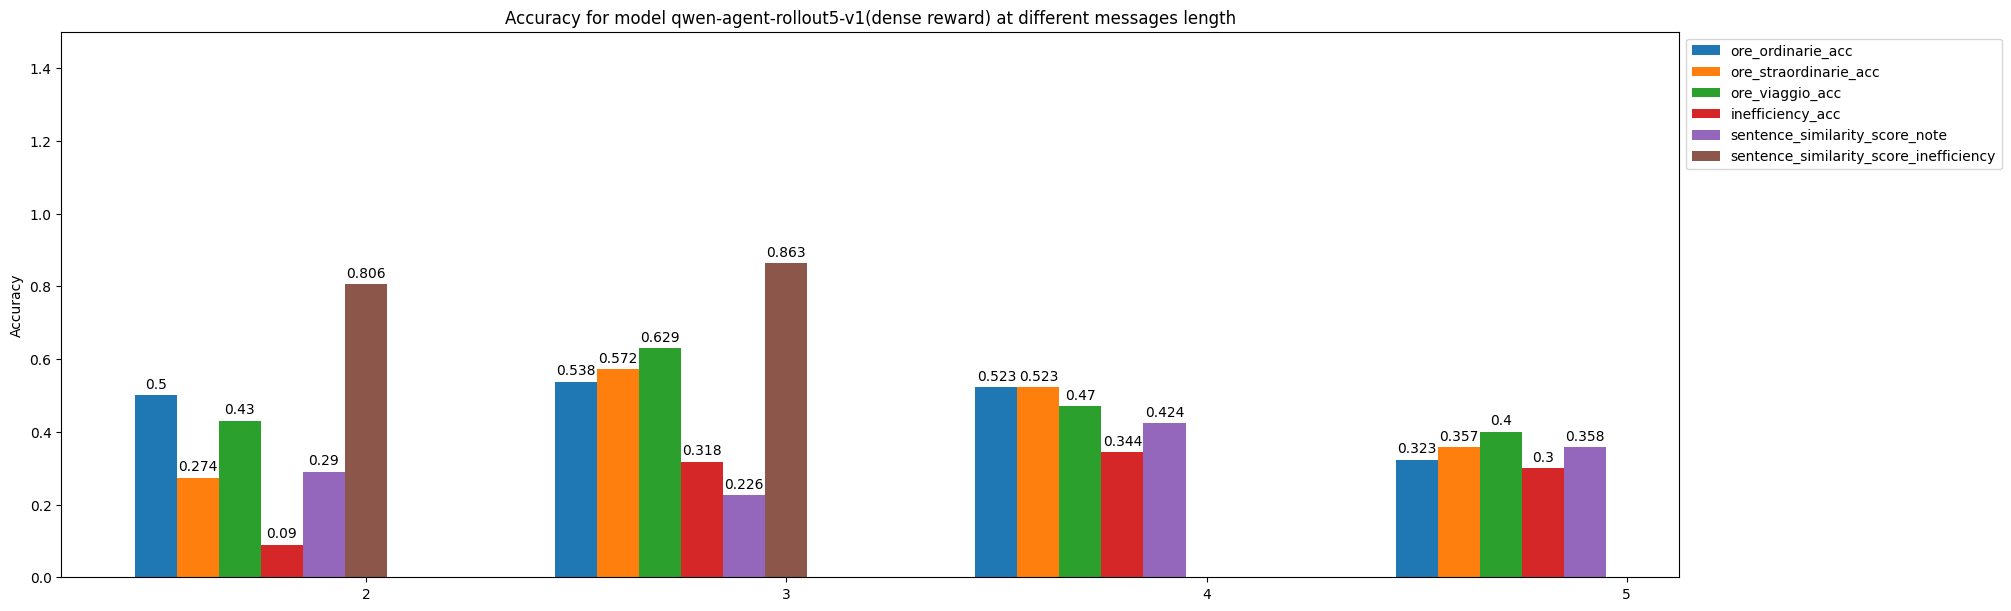

In [32]:
# chart per fare il display accuracy totale  al variare del flow


l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {label} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)

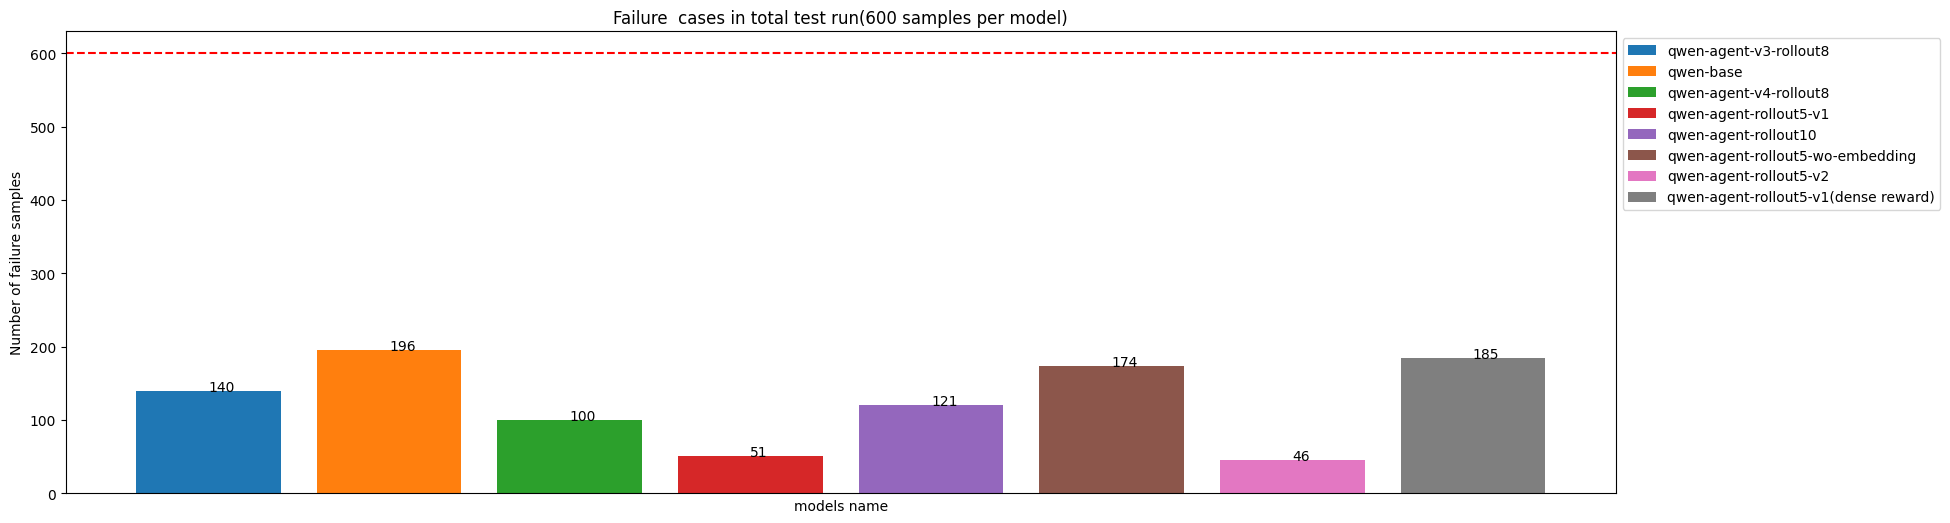

In [31]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

dict_results = {}
for model in models:
    dict_results[model] = df.loc[df['model'] == model]['failure_reason'].notna().sum() 

data = dict_results.values()
#labels = dict_results.keys()

plt.figure(figsize=(20,6))
plt.bar(labels, data, color=colors, label=labels)
add_labels(labels,list(data))
plt.axhline(y=len(df.loc[df['model'] == models[0]]), color='red', linestyle='--', linewidth=1.5)
plt.title("Failure  cases in total test run(600 samples per model)")
plt.xlabel("models name")
plt.ylabel("Number of failure samples")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Esperimento agent wo il reward con gli embedding del summary

In [41]:
df['model'].unique()

<StringArray>
[                'qwen-chat-agent-4-v2',
                       'chat-qwen-base',
                    'qwen-chat-agent-6',
                     'qwen-extractor-3',
                     'qwen-extractor-4',
                     'qwen-extractor-2',
 'qwen-chat-extractor-tuned-lora-16-v1',
                 'qwen-chat-agent-5-v1',
                    'qwen-chat-agent-7',
       'qwen-chat-agent-8-wo-embedding',
                   'qwen-chat-agent-12']
Length: 11, dtype: str

In [43]:
target ='base|qwen-chat-agent-8-wo-embedding|qwen-chat-agent-5-v1'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen-base','w. embedding reward','w.o. embedding reward']
models

['chat-qwen-base', 'qwen-chat-agent-5-v1', 'qwen-chat-agent-8-wo-embedding']

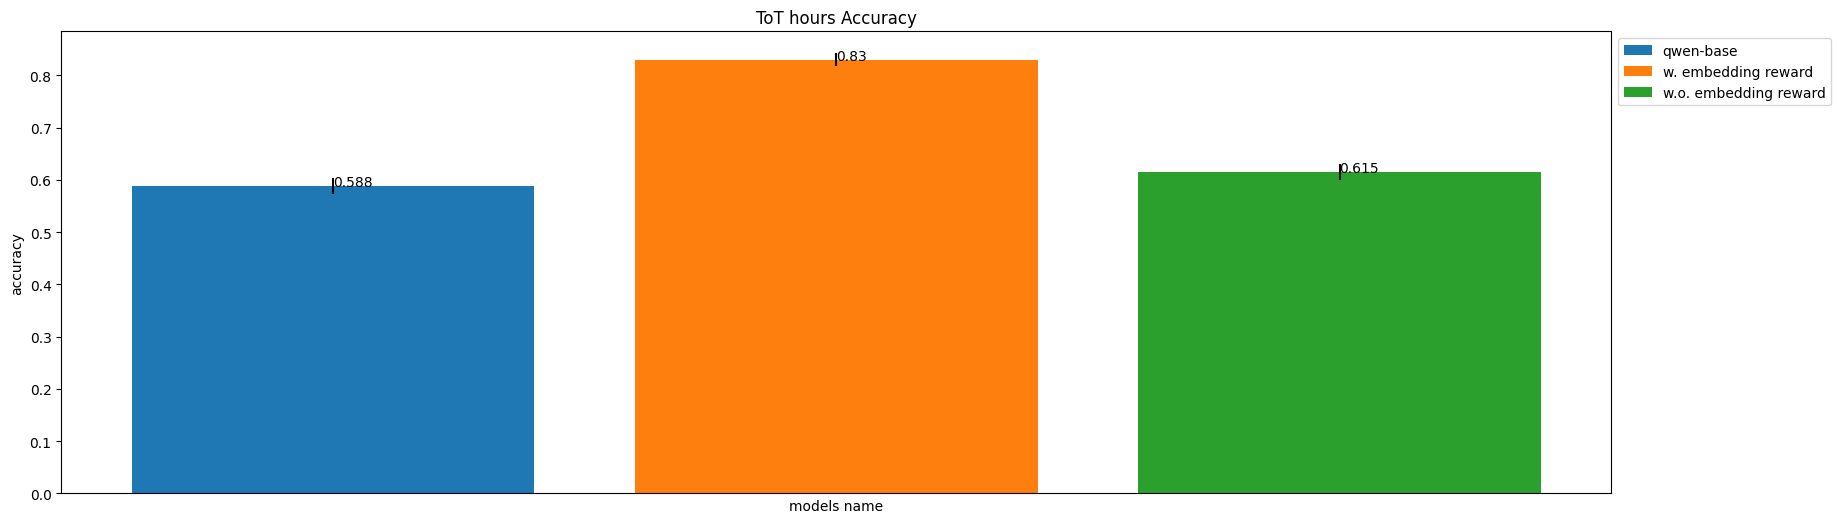

In [44]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    acc_media = round(df.loc[(df['model'] == model)  ]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors , label=labels)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

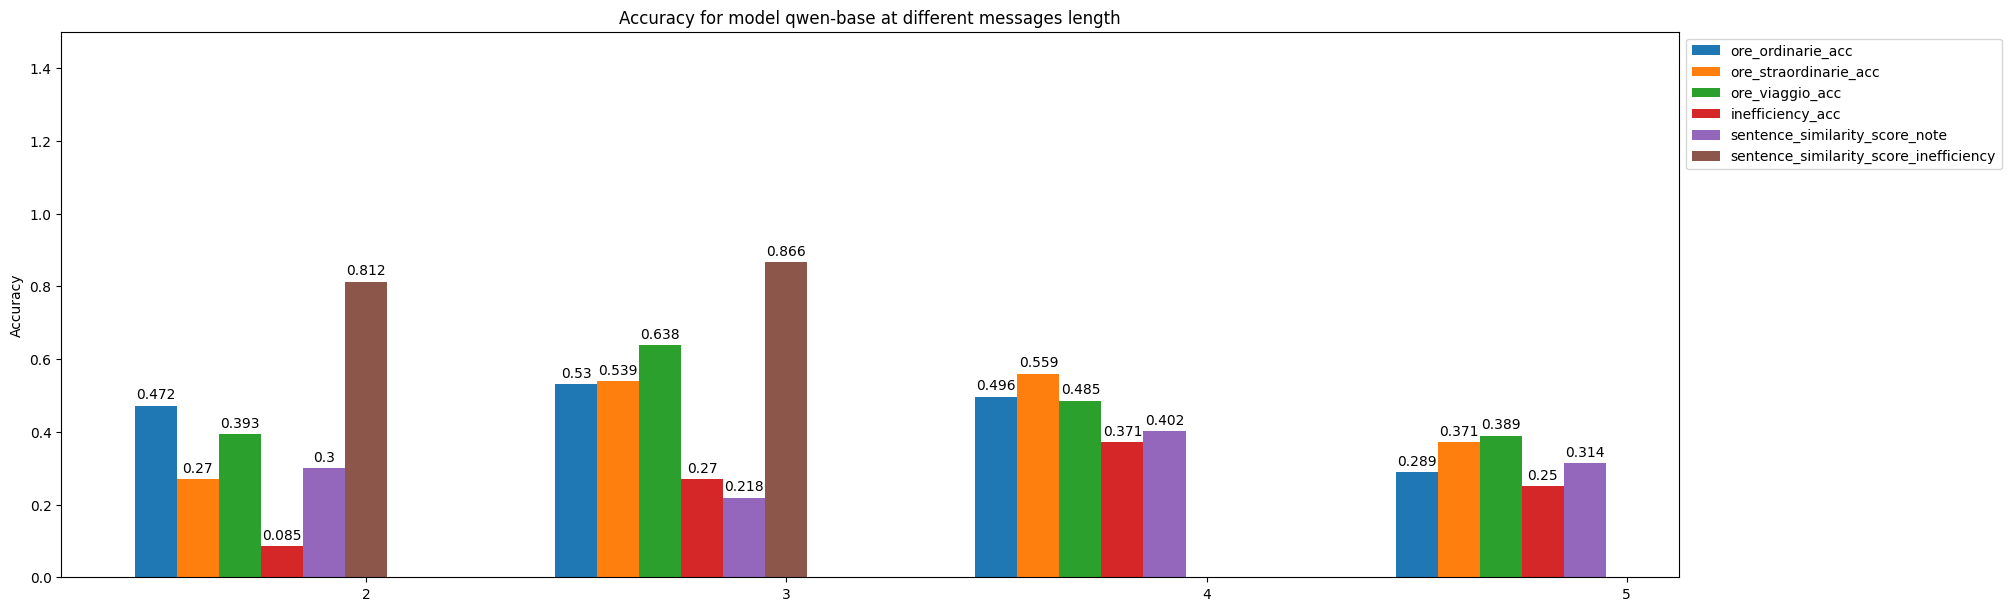

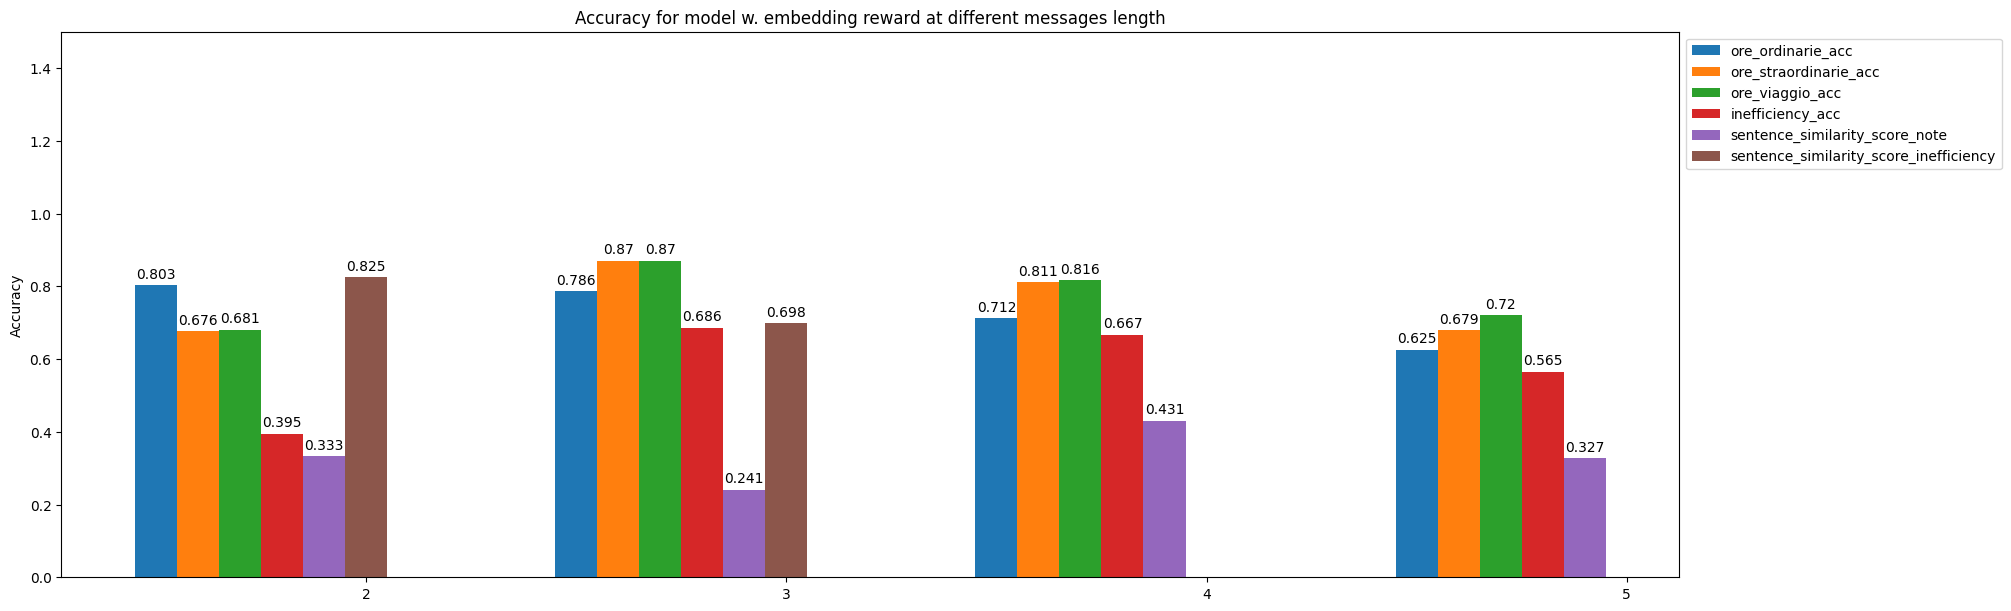

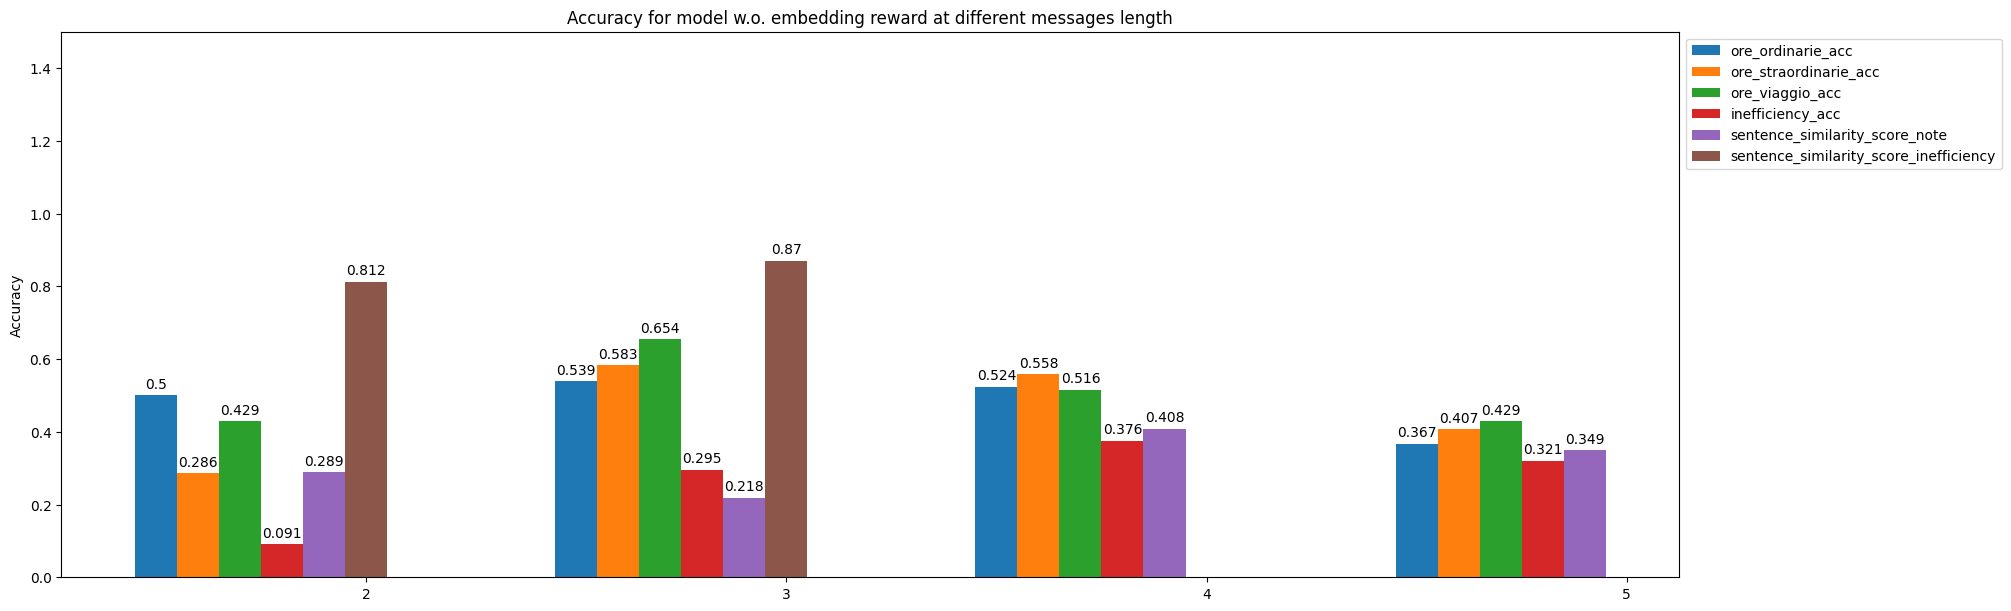

In [45]:
# chart per fare il display accuracy totale  al variare del flow


l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {label} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)

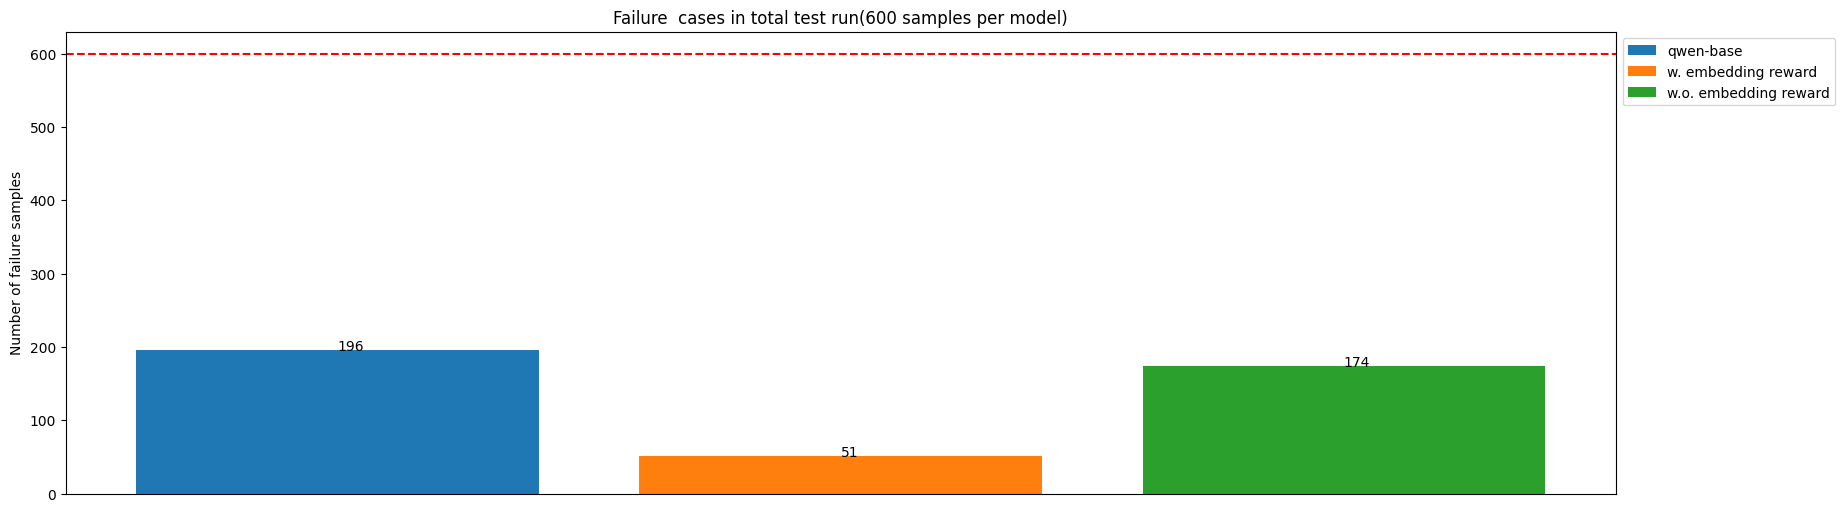

In [47]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

dict_results = {}
for model in models:
    dict_results[model] = df.loc[df['model'] == model]['failure_reason'].notna().sum() 

data = dict_results.values()
#labels = dict_results.keys()

plt.figure(figsize=(20,6))
plt.bar(labels, data, color=colors, label=labels)
add_labels(labels,list(data))
plt.axhline(y=len(df.loc[df['model'] == models[0]]), color='red', linestyle='--', linewidth=1.5)
plt.title("Failure  cases in total test run(600 samples per model)")
plt.ylabel("Number of failure samples")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Confronto finale con agent + extractor
TODO: qua testati assieme il training dell'agent `qwen-chat-agent-4-v2` + `qwen-extractor-4`. é necessario testare con il traning dell'agent migliore `qwen-chat-agent-5-v1`.

In [48]:
df['model'].unique()

<StringArray>
[                'qwen-chat-agent-4-v2',
                       'chat-qwen-base',
                    'qwen-chat-agent-6',
                     'qwen-extractor-3',
                     'qwen-extractor-4',
                     'qwen-extractor-2',
 'qwen-chat-extractor-tuned-lora-16-v1',
                 'qwen-chat-agent-5-v1',
                    'qwen-chat-agent-7',
       'qwen-chat-agent-8-wo-embedding',
                   'qwen-chat-agent-12']
Length: 11, dtype: str

In [49]:
target ='base|qwen-chat-extractor-tuned-lora-16-v1'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen-base','qwen-grpo-tuned']
models

['chat-qwen-base', 'qwen-chat-extractor-tuned-lora-16-v1']

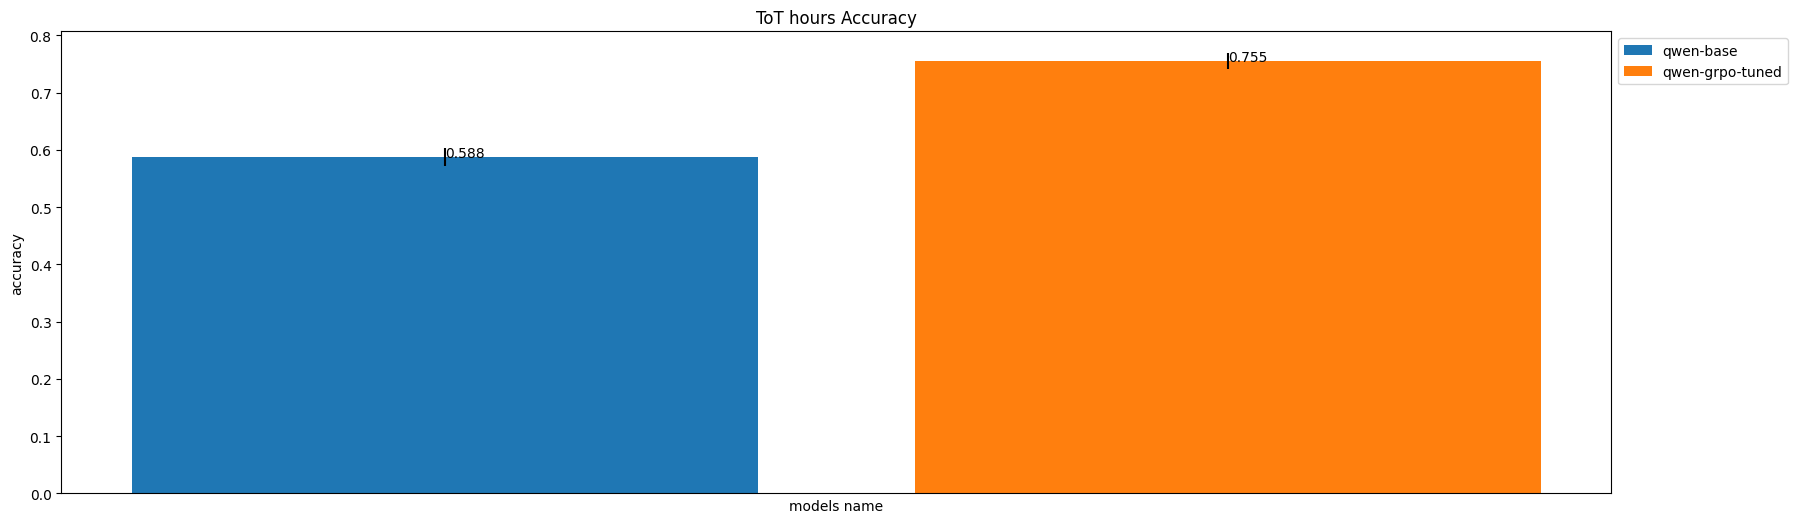

In [50]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    acc_media = round(df.loc[(df['model'] == model)  ]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors , label=labels)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

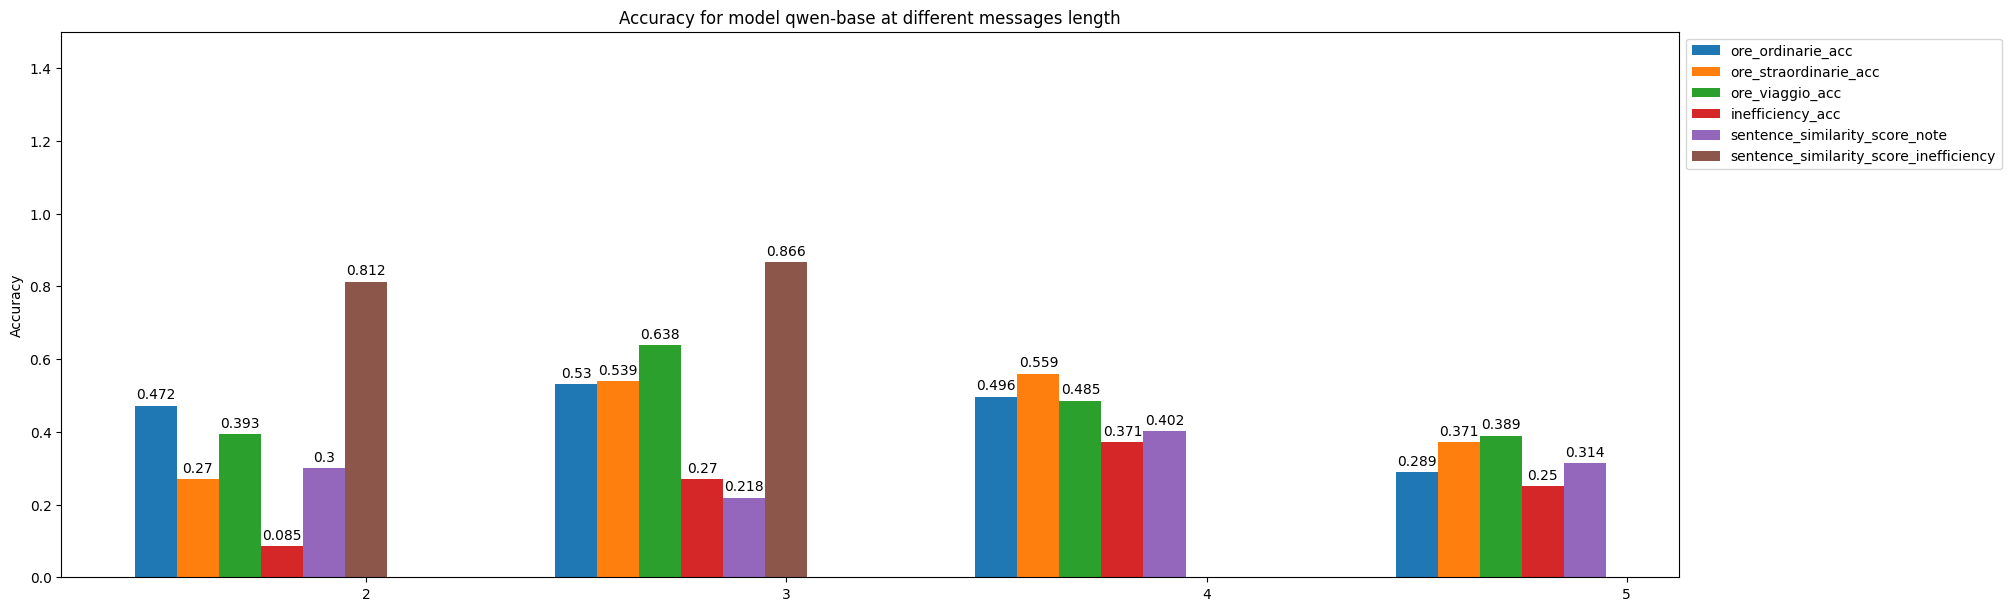

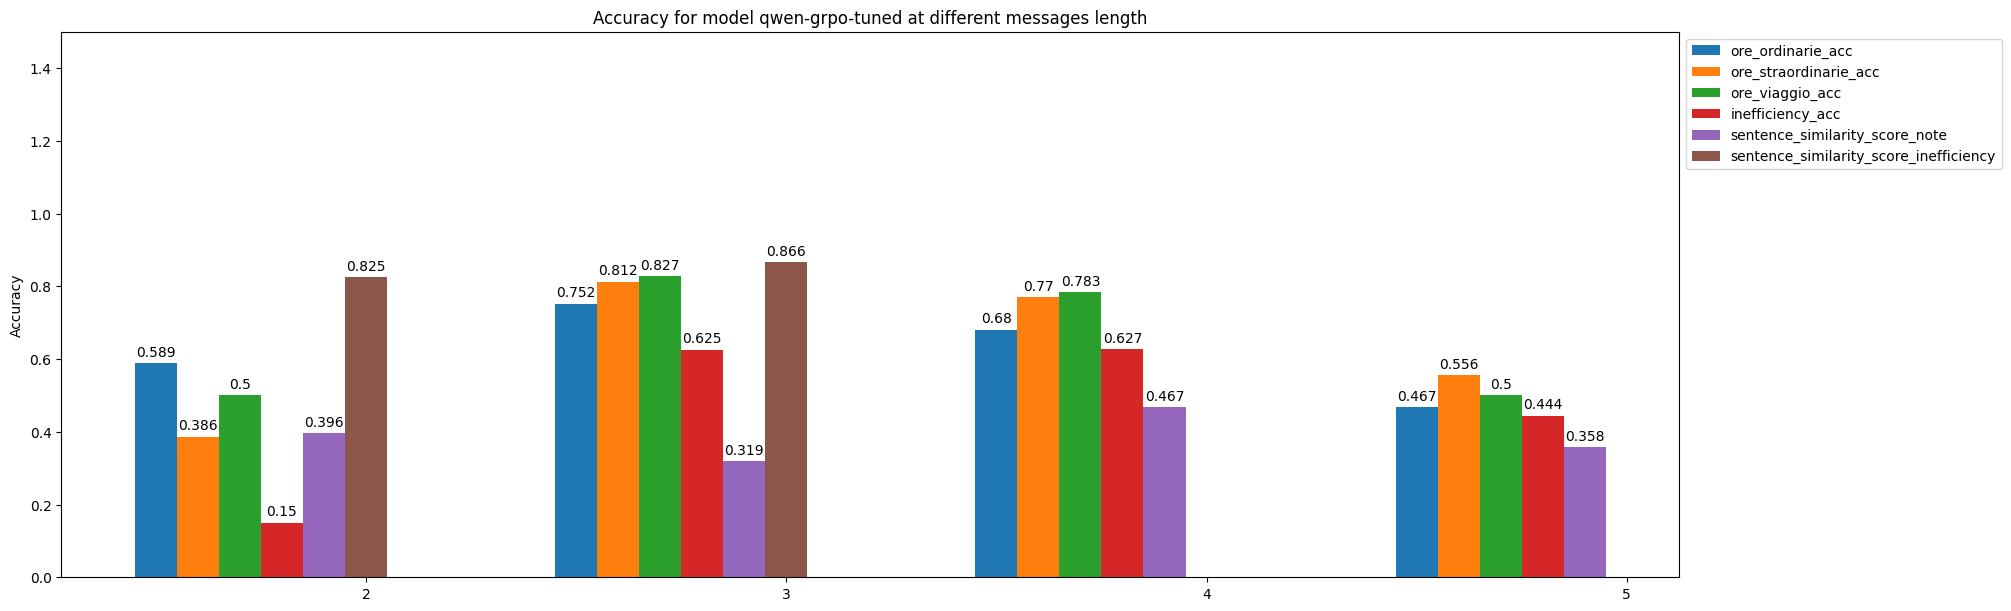

In [51]:
# chart per fare il display accuracy totale  al variare del flow


l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {label} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)

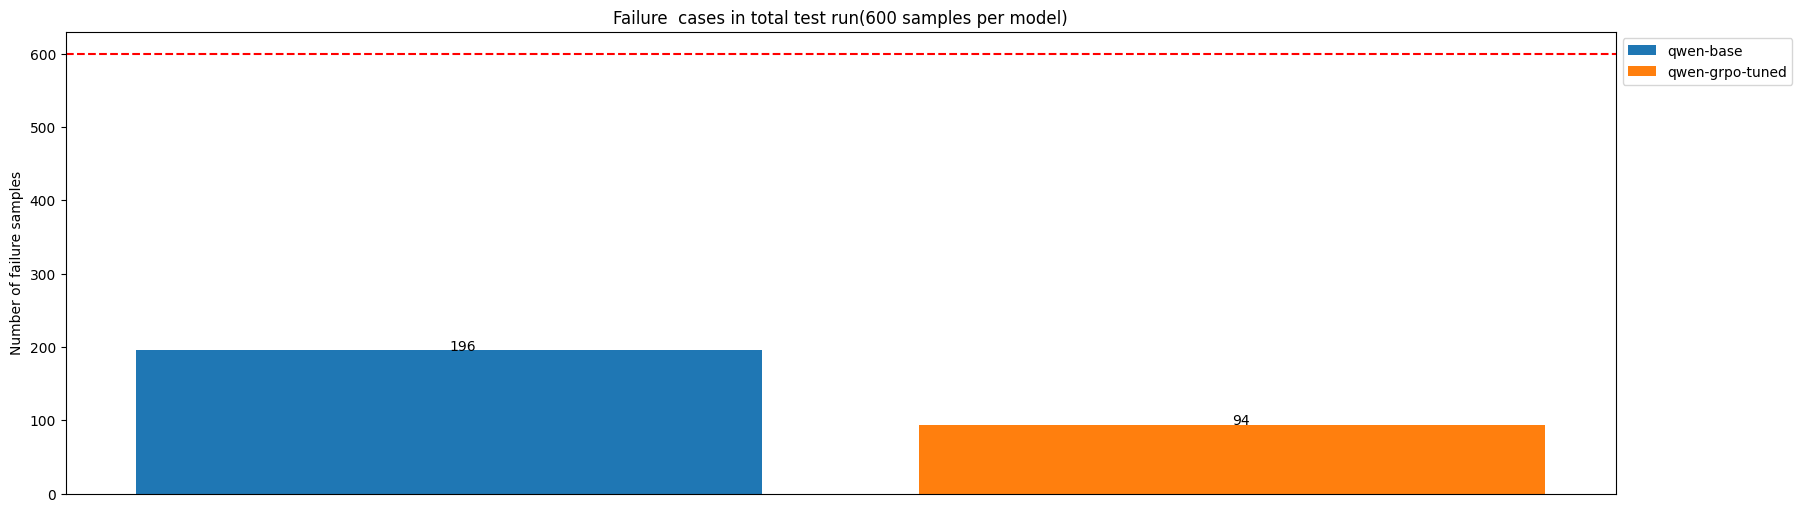

In [52]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

dict_results = {}
for model in models:
    dict_results[model] = df.loc[df['model'] == model]['failure_reason'].notna().sum() 

data = dict_results.values()
#labels = dict_results.keys()

plt.figure(figsize=(20,6))
plt.bar(labels, data, color=colors, label=labels)
add_labels(labels,list(data))
plt.axhline(y=len(df.loc[df['model'] == models[0]]), color='red', linestyle='--', linewidth=1.5)
plt.title("Failure  cases in total test run(600 samples per model)")
plt.ylabel("Number of failure samples")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))